In [1]:
import pandas as pd

C:\Users\kumar_santhosh\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\kumar_santhosh\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:
df_1 = pd.read_csv('2.cleaned_data.csv')
df_1.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [3]:
df_2 = pd.read_csv('4.X_scaled.csv')
df_2.head()

,Income,Age,Customer_Days,Recency,Total_Spending,Total_Purchases,Total_Children
0,0.288513,1.016868,1.529793,0.306856,1.680176,1.319340,-1.264308
1,-0.262438,1.273264,-1.191143,-0.383971,-0.962202,-1.155857,1.395139
2,0.917992,0.333146,-0.206659,-0.798467,0.282541,0.798246,-1.264308
3,-1.182621,-1.290693,-1.062517,-0.798467,-0.918994,-0.895310,0.065416
4,0.295754,-1.034298,-0.953679,1.550344,-0.305762,0.537699,0.065416


In [4]:
df_3 = pd.read_csv('clustered_data.csv')
df_3.head()

,Income,Recency,Customer_Days,Total_Spending,Total_Purchases,Cluster
0,0.288513,0.306856,1.529793,1.680176,1.319340,3
1,-0.262438,-0.383971,-1.191143,-0.962202,-1.155857,1
2,0.917992,-0.798467,-0.206659,0.282541,0.798246,2
3,-1.182621,-0.798467,-1.062517,-0.918994,-0.895310,1
4,0.295754,1.550344,-0.953679,-0.305762,0.537699,3


In [12]:
cols_1 = ['Income', 'Recency']

In [13]:
df_p_1 = df_1[cols_1]
df_p_1.head()

,Income,Recency
0,58138.0,58
1,46344.0,38
2,71613.0,26
3,26646.0,26
4,58293.0,94


In [9]:
df_1.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='str')

In [16]:
from datetime import datetime
df_p_1['Dt_Customer'] = pd.to_datetime(df_1['Dt_Customer'], dayfirst=True)
df_p_1['Customer_Days'] = (datetime.now() - df_p_1['Dt_Customer']).dt.days
df_p_1.drop('Dt_Customer', axis=1, inplace=True)

In [17]:
df_p_1['Total_Spending'] = (
    df_1['MntWines'] +
    df_1['MntFruits'] +
    df_1['MntMeatProducts'] +
    df_1['MntFishProducts'] +
    df_1['MntSweetProducts'] +
    df_1['MntGoldProds'])

In [19]:
df_p_1['Total_Purchases'] = (df_1['NumWebPurchases'] +df_1['NumCatalogPurchases'] +df_1['NumStorePurchases']+ df_1['NumDealsPurchases'])

In [20]:
df_p_1['Clusters'] = df_3['Cluster']
df_p_1.head()

,Income,Recency,Customer_Days,Total_Spending,Total_Purchases,Clusters
0,58138.0,58,4951,1617,25,3.0
1,46344.0,38,4401,27,6,1.0
2,71613.0,26,4600,776,21,2.0
3,26646.0,26,4427,53,8,1.0
4,58293.0,94,4449,422,19,3.0


In [22]:
cluster_profile = df_p_1.groupby('Clusters').mean()
cluster_profile

,Income,Recency,Customer_Days,Total_Spending,Total_Purchases
Clusters,,,,,
0.0,50256.261539,47.485240,4669.750923,563.335793,14.546125
1.0,50390.062032,49.623256,4623.308527,554.848062,14.038760
2.0,54278.999002,47.659229,4634.521298,655.572008,15.835700
3.0,54479.683021,51.384892,4642.413669,661.665468,15.233813


In [23]:
cluster_counts = df_p_1['Clusters'].value_counts().sort_index()
cluster_profile['Count'] = cluster_counts
cluster_profile

,Income,Recency,Customer_Days,Total_Spending,Total_Purchases,Count
Clusters,,,,,,
0.0,50256.261539,47.485240,4669.750923,563.335793,14.546125,542
1.0,50390.062032,49.623256,4623.308527,554.848062,14.038760,645
2.0,54278.999002,47.659229,4634.521298,655.572008,15.835700,493
3.0,54479.683021,51.384892,4642.413669,661.665468,15.233813,556


In [24]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
cluster_profile_scaled = pd.DataFrame(
    scaler.fit_transform(cluster_profile),
    columns=cluster_profile.columns,
    index=cluster_profile.index
)

cluster_profile_scaled

,Income,Recency,Customer_Days,Total_Spending,Total_Purchases,Count
Clusters,,,,,,
0.0,0.000000,0.000000,1.000000,0.079460,0.282350,0.322368
1.0,0.031681,0.548258,0.000000,0.000000,0.000000,1.000000
2.0,0.952483,0.044617,0.241434,0.942954,1.000000,0.000000
3.0,1.000000,1.000000,0.411373,1.000000,0.665049,0.414474


In [26]:
cluster_names = {
    0: "High Value Customers",
    1: "New Customers",
    2: "At Risk Customers",
    3: "Budget Buyers"
}

df_p_1['Segment'] = df_p_1['Clusters'].map(cluster_names)

In [27]:
cluster_profile

,Income,Recency,Customer_Days,Total_Spending,Total_Purchases,Count
Clusters,,,,,,
0.0,50256.261539,47.485240,4669.750923,563.335793,14.546125,542
1.0,50390.062032,49.623256,4623.308527,554.848062,14.038760,645
2.0,54278.999002,47.659229,4634.521298,655.572008,15.835700,493
3.0,54479.683021,51.384892,4642.413669,661.665468,15.233813,556


<Axes: xlabel='Clusters'>

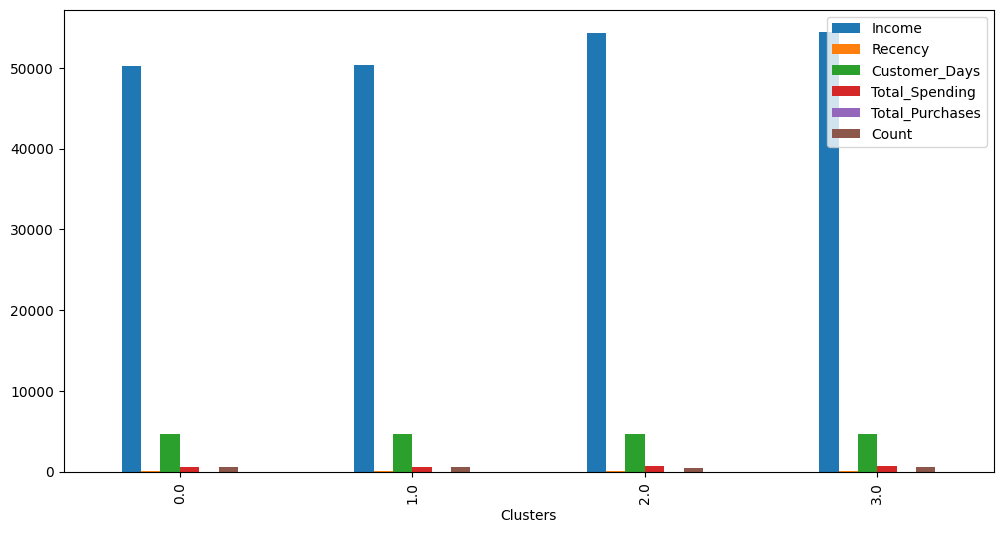

In [28]:
cluster_profile.plot(kind='bar', figsize=(12,6))

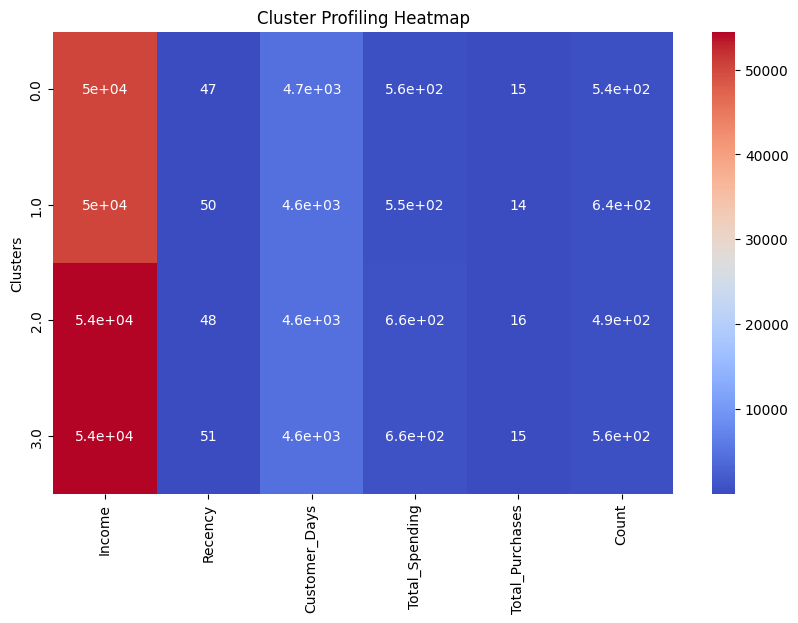

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(cluster_profile, annot=True, cmap='coolwarm')
plt.title("Cluster Profiling Heatmap")
plt.show()

In [30]:
df_p_1.to_csv("segmented_customers.csv", index=False)
cluster_profile.to_csv("cluster_profile.csv")